# Figure 5a: TCN response rate versus maximum PCN capacity

This notebook generates the modeled capacity sweep in Figure 5a. Maximum PCN capacity is a model state-space limit and is distinct from the experimentally measured mean PCN used in Figure 5b.


In [1]:
%matplotlib inline
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.environ.setdefault("SIM_RUN_MODE", "production")
%run ./simulation_core.ipynb
plt.rcParams.update(PLOT_STYLE)

OUTPUT_ROOT, FIGURE_DIR, SOURCE_DIR = make_output_dirs("Figure5_outputs")
PCN_CAPACITY_GRID = (np.array([20, 40, 60, 80, 100], dtype=int)
                     if RUN_MODE == "quick" else np.arange(20, 101, 5, dtype=int))
CONDITIONS = ("transposition on", "transposition off")


## Converged capacity sweep

Each capacity is converged independently under the same five-relaxed/two-selected passage cycle. Runs that do not satisfy the shared survival criterion retain missing response rates.


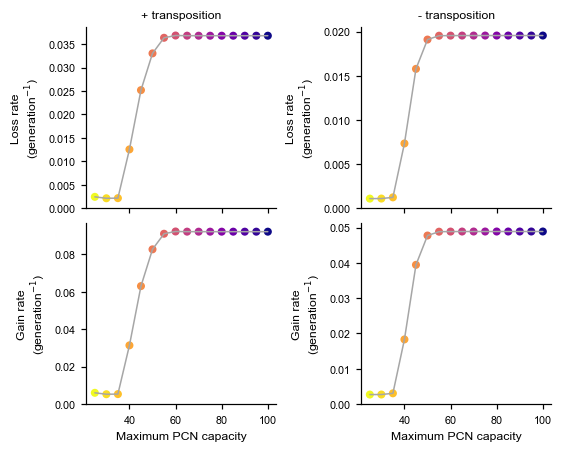

In [2]:
rows=[]
for max_pcn in PCN_CAPACITY_GRID:
    configs={c.condition:c for c in standard_configurations(int(max_pcn))}
    for condition in CONDITIONS:
        rows.append(evaluate_configuration(int(max_pcn), configs[condition]))
results=pd.DataFrame(rows)

fig, axes = plt.subplots(2, 2, figsize=(5.0, 4.0), sharex='col', constrained_layout=True)
for col, condition in enumerate(CONDITIONS):
    d=results[(results.condition==condition) & results.response_valid].sort_values("maximum_PCN")
    for row, metric, ylabel in ((0,"loss_rate","Loss rate\n(generation$^{-1}$)"),
                                (1,"gain_rate","Gain rate\n(generation$^{-1}$)")):
        ax=axes[row,col]
        ax.plot(d.maximum_PCN, d[metric], color="0.65", lw=1)
        ax.scatter(d.maximum_PCN, d[metric], c=d.maximum_PCN, cmap="plasma_r", s=18)
        ax.set_ylim(bottom=0)
        ax.set_ylabel(ylabel)
        if row==1: ax.set_xlabel("Maximum PCN capacity")
    axes[0,col].set_title("+ transposition" if condition=="transposition on" else "- transposition")
save_figure(fig, "Figure5a_capacity_response", FIGURE_DIR)
plt.show()

export_table(results, "Figure5a_source_data.csv", SOURCE_DIR)
export_table(core_metadata("Figure 5a"), "Figure5a_run_metadata.csv", SOURCE_DIR)
